# Discriminative Neuron Analysis

**Purpose**: Analyze discriminative neurons in BERT for AI vs Human text classification.

## Structure
- **Section A**: Neuron Discovery & Distribution
- **Section B**: Activation Pattern Analysis
- **Section C**: Statistical Validation

## Outputs for Paper
- Table 1: Summary statistics
- Figure 1: Layer-wise distribution
- Figure 2: Activation patterns (top-10 neurons)
- Figure 3: Mean activation scatter (AI vs Human)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_PATH = Path('../results/activations')
FIGURES_PATH = Path('../results/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
ALL_LAYERS = list(range(1, 13))
NEURONS_PER_LAYER = 768
TOTAL_NEURONS = NEURONS_PER_LAYER * len(ALL_LAYERS)

In [12]:
# Load all neuron statistics
all_stats = []
for layer in ALL_LAYERS:
    df = pd.read_csv(RESULTS_PATH / f'layer_{layer}_neuron_stats.csv')
    df['layer'] = layer
    all_stats.append(df)

neurons_df = pd.concat(all_stats, ignore_index=True)
disc_df = neurons_df[neurons_df['discriminative']].copy()

labels = np.load(RESULTS_PATH / 'labels.npy')
ai_mask = labels == 1
human_mask = labels == 0

print(f'Loaded {len(neurons_df)} neurons from {len(ALL_LAYERS)} layers')
print(f'Discriminative neurons: {len(disc_df)}')
print(f'Samples: {len(labels)} (AI: {ai_mask.sum()}, Human: {human_mask.sum()})')

Loaded 9216 neurons from 12 layers
Discriminative neurons: 1350
Samples: 3000 (AI: 1500, Human: 1500)


---
# Section A: Neuron Discovery & Distribution
Find discriminative neurons, count them, see where they are in BERT layers.

In [13]:
# === TABLE 1: Summary Statistics ===
n_total = len(neurons_df)
n_discriminative = len(disc_df)
n_ai_pref = (disc_df['auc'] > 0.7).sum()
n_human_pref = (disc_df['auc'] < 0.3).sum()

# Layer-wise counts
layer_counts = disc_df.groupby('layer').size()
peak_layer = layer_counts.idxmax()
peak_count = layer_counts.max()

# Layer groups
early = disc_df[disc_df['layer'] <= 4]
middle = disc_df[(disc_df['layer'] >= 5) & (disc_df['layer'] <= 8)]
late = disc_df[disc_df['layer'] >= 9]

print('='*60)
print('TABLE 1: DISCRIMINATIVE NEURON SUMMARY')
print('='*60)
print(f"{'Metric':<40} {'Value':>15}")
print('-'*60)
print(f"{'Total BERT neurons analyzed':<40} {n_total:>15,}")
print(f"{'Discriminative neurons identified':<40} {n_discriminative:>15,}")
print(f"{'Percentage of total':<40} {n_discriminative/n_total*100:>14.1f}%")
print('-'*60)
print(f"{'AI-preferring (AUC > 0.7)':<40} {n_ai_pref:>15,}")
print(f"{'Human-preferring (AUC < 0.3)':<40} {n_human_pref:>15,}")
print(f"{'AI:Human ratio':<40} {n_ai_pref/max(n_human_pref,1):>14.2f}:1")
print(f"{'Mean AUC deviation from 0.5':<40} {disc_df['auc_deviation'].mean():>15.3f}")
print('-'*60)
print(f"{'Early layers (1-4)':<40} {len(early):>15,}")
print(f"{'Middle layers (5-8)':<40} {len(middle):>15,}")
print(f"{'Late layers (9-12)':<40} {len(late):>15,}")
print(f"{'Peak layer':<40} {'Layer ' + str(peak_layer):>15}")
print('='*60)

TABLE 1: DISCRIMINATIVE NEURON SUMMARY
Metric                                             Value
------------------------------------------------------------
Total BERT neurons analyzed                        9,216
Discriminative neurons identified                  1,350
Percentage of total                                14.6%
------------------------------------------------------------
AI-preferring (AUC > 0.7)                            688
Human-preferring (AUC < 0.3)                         662
AI:Human ratio                                     1.04:1
Mean AUC deviation from 0.5                        0.243
------------------------------------------------------------
Early layers (1-4)                                   438
Middle layers (5-8)                                  308
Late layers (9-12)                                   604
Peak layer                                      Layer 11


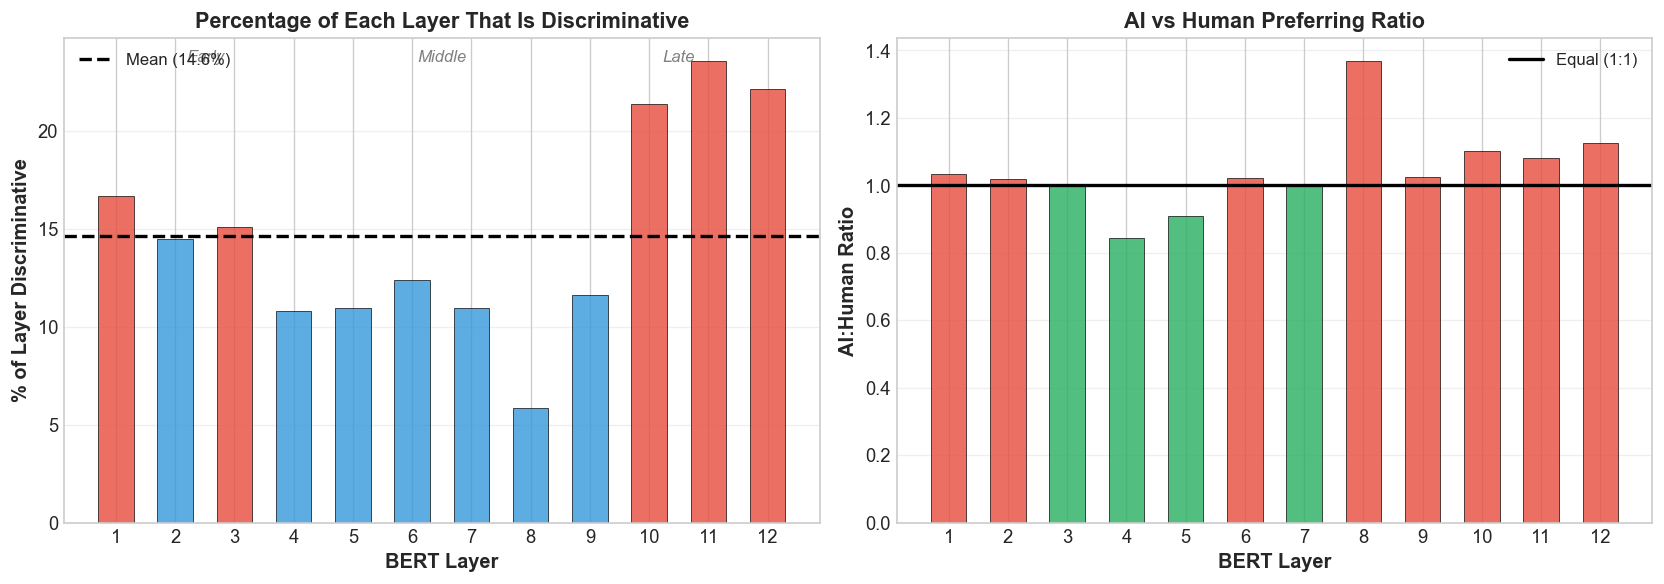

Saved: ..\results\figures\figure1_layer_distribution.png


In [14]:
# === FIGURE 1: Layer-wise Distribution ===
layer_stats = []
for layer in ALL_LAYERS:
    lyr_neurons = neurons_df[neurons_df['layer'] == layer]
    lyr_disc = lyr_neurons[lyr_neurons['discriminative']]
    layer_stats.append({
        'layer': layer,
        'total': len(lyr_neurons),
        'discriminative': len(lyr_disc),
        'pct_discriminative': len(lyr_disc) / len(lyr_neurons) * 100,
        'ai_preferring': (lyr_disc['auc'] > 0.7).sum(),
        'human_preferring': (lyr_disc['auc'] < 0.3).sum()
    })
layer_df = pd.DataFrame(layer_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = layer_df['layer']
width = 0.6

# Plot 1: Percentage discriminative per layer
ax = axes[0]
mean_pct = layer_df['pct_discriminative'].mean()
colors = ['#e74c3c' if pct >= mean_pct else '#3498db' for pct in layer_df['pct_discriminative']]
ax.bar(x, layer_df['pct_discriminative'], width, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(mean_pct, color='black', linestyle='--', linewidth=2, label=f'Mean ({mean_pct:.1f}%)')
ax.set_xlabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('% of Layer Discriminative', fontsize=12, fontweight='bold')
ax.set_title('Percentage of Each Layer That Is Discriminative', fontsize=13, fontweight='bold')
ax.set_xticks(ALL_LAYERS)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add layer group annotations
ylim = ax.get_ylim()[1]
ax.text(2.5, ylim*0.95, 'Early', ha='center', fontsize=10, fontstyle='italic', color='gray')
ax.text(6.5, ylim*0.95, 'Middle', ha='center', fontsize=10, fontstyle='italic', color='gray')
ax.text(10.5, ylim*0.95, 'Late', ha='center', fontsize=10, fontstyle='italic', color='gray')

# Plot 2: AI vs Human ratio per layer
ax = axes[1]
ratio = layer_df['ai_preferring'] / layer_df['human_preferring'].replace(0, 1)
colors = ['#e74c3c' if r > 1 else '#27ae60' for r in ratio]
ax.bar(x, ratio, width, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(1, color='black', linestyle='-', linewidth=2, label='Equal (1:1)')
ax.set_xlabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('AI:Human Ratio', fontsize=12, fontweight='bold')
ax.set_title('AI vs Human Preferring Ratio', fontsize=13, fontweight='bold')
ax.set_xticks(ALL_LAYERS)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'figure1_layer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_PATH / "figure1_layer_distribution.png"}')

In [15]:
# Top-K identification
top20 = disc_df.nlargest(20, 'auc_deviation')[['layer', 'neuron_idx', 'auc', 'p_value', 'direction']]
top20['rank'] = range(1, 21)
top20 = top20[['rank', 'layer', 'neuron_idx', 'auc', 'p_value', 'direction']]

print('TOP-20 DISCRIMINATIVE NEURONS')
print('='*70)
print(top20.to_string(index=False))
print('='*70)
print(f"Top-20 are from layers: {sorted(top20['layer'].unique())}")
print(f"Mean AUC deviation from 0.5: {disc_df.nlargest(20, 'auc_deviation')['auc_deviation'].mean():.3f}")

TOP-20 DISCRIMINATIVE NEURONS
 rank  layer  neuron_idx      auc      p_value        direction
    1     12         301 0.097929 1.299460e-95 Human-preferring
    2     12         682 0.893891 7.717703e-92    AI-preferring
    3     12         381 0.884193 1.824399e-87    AI-preferring
    4     12         522 0.882712 8.309862e-87    AI-preferring
    5     10         682 0.880452 8.306924e-86    AI-preferring
    6     12           2 0.121493 5.958665e-85 Human-preferring
    7      4          46 0.873201 1.222765e-82    AI-preferring
    8     11         187 0.130547 5.024854e-81 Human-preferring
    9     11         301 0.131542 1.339075e-80 Human-preferring
   10     12         481 0.136301 1.402710e-78 Human-preferring
   11     11         437 0.137683 5.355736e-78 Human-preferring
   12     12         679 0.859408 8.830310e-77    AI-preferring
   13     11         239 0.141069 1.395608e-76 Human-preferring
   14     12         446 0.141681 2.508576e-76 Human-preferring
   15     

---
# Section B: Activation Pattern Analysis
How do discriminative neurons actually behave on AI vs human text?

In [16]:
# Compute activation statistics for all discriminative neurons
disc_df['mean_diff'] = disc_df['ai_median'] - disc_df['human_median']
disc_df['activation_direction'] = np.where(disc_df['mean_diff'] > 0, 'Higher for AI', 'Higher for Human')

# Variance proxy using IQR
disc_df['ai_iqr'] = disc_df['ai_q75'] - disc_df['ai_q25']
disc_df['human_iqr'] = disc_df['human_q75'] - disc_df['human_q25']
disc_df['variance_ratio'] = disc_df['ai_iqr'] / disc_df['human_iqr'].replace(0, 1e-10)

# Cohen's d approximation
pooled_iqr = (disc_df['ai_iqr'] + disc_df['human_iqr']) / 2 / 1.35
disc_df['cohens_d'] = disc_df['mean_diff'] / pooled_iqr.replace(0, 1e-10)

print('ACTIVATION PATTERN SUMMARY')
print('='*50)
print(f'Direction of discrimination:')
print(f"  Higher activation for AI: {(disc_df['mean_diff'] > 0).sum()}")
print(f"  Higher activation for Human: {(disc_df['mean_diff'] < 0).sum()}")
print(f'Effect sizes (Cohen\'s d):')
print(f"  Mean |d|: {disc_df['cohens_d'].abs().mean():.3f}")
print(f"  Median |d|: {disc_df['cohens_d'].abs().median():.3f}")
print(f"  Large effects (|d| > 0.8): {(disc_df['cohens_d'].abs() > 0.8).sum()}")
print(f'Variance ratio (AI/Human):')
print(f"  Mean: {disc_df['variance_ratio'].mean():.3f}")
print(f"  AI more consistent (ratio < 1): {(disc_df['variance_ratio'] < 1).sum()}")
print(f"  Human more consistent (ratio > 1): {(disc_df['variance_ratio'] > 1).sum()}")

ACTIVATION PATTERN SUMMARY
Direction of discrimination:
  Higher activation for AI: 688
  Higher activation for Human: 662
Effect sizes (Cohen's d):
  Mean |d|: 0.967
  Median |d|: 0.925
  Large effects (|d| > 0.8): 1138
Variance ratio (AI/Human):
  Mean: 1.125
  AI more consistent (ratio < 1): 319
  Human more consistent (ratio > 1): 1031


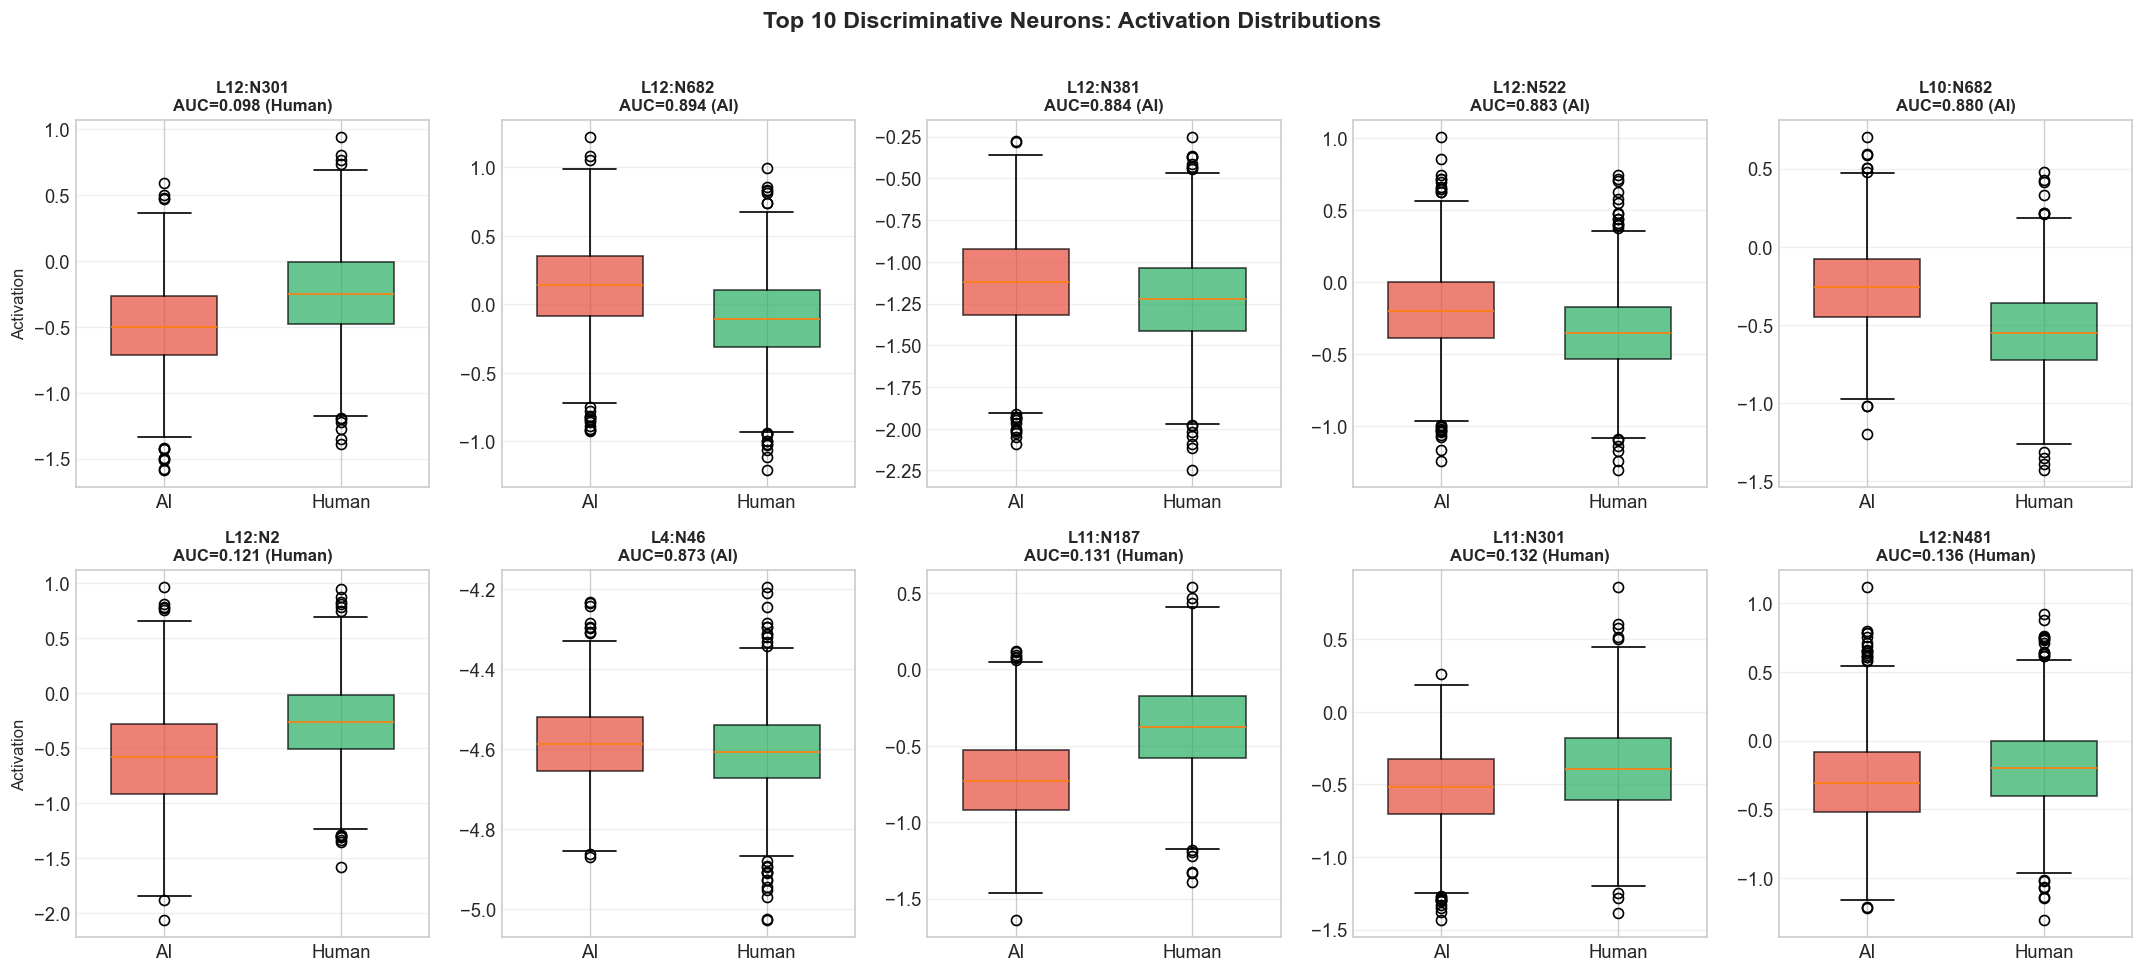

Saved: ..\results\figures\figure2_activation_boxplots.png


In [17]:
# === FIGURE 2: Top-10 Neuron Activation Boxplots ===
top10 = disc_df.nlargest(10, 'auc_deviation')

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, (_, neuron) in enumerate(top10.iterrows()):
    layer = int(neuron['layer'])
    neuron_idx = int(neuron['neuron_idx'])
    auc = neuron['auc']
    
    layer_acts = np.load(RESULTS_PATH / f'layer_{layer}_activations.npy')
    neuron_acts = layer_acts[:, neuron_idx]
    
    ax = axes[idx]
    bp = ax.boxplot([neuron_acts[ai_mask], neuron_acts[human_mask]],
                     tick_labels=['AI', 'Human'], patch_artist=True, widths=0.6)
    
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#27ae60')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_alpha(0.7)
    
    pref = 'AI' if auc > 0.5 else 'Human'
    ax.set_title(f'L{layer}:N{neuron_idx}\nAUC={auc:.3f} ({pref})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Activation' if idx % 5 == 0 else '', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Top 10 Discriminative Neurons: Activation Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'figure2_activation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_PATH / "figure2_activation_boxplots.png"}')

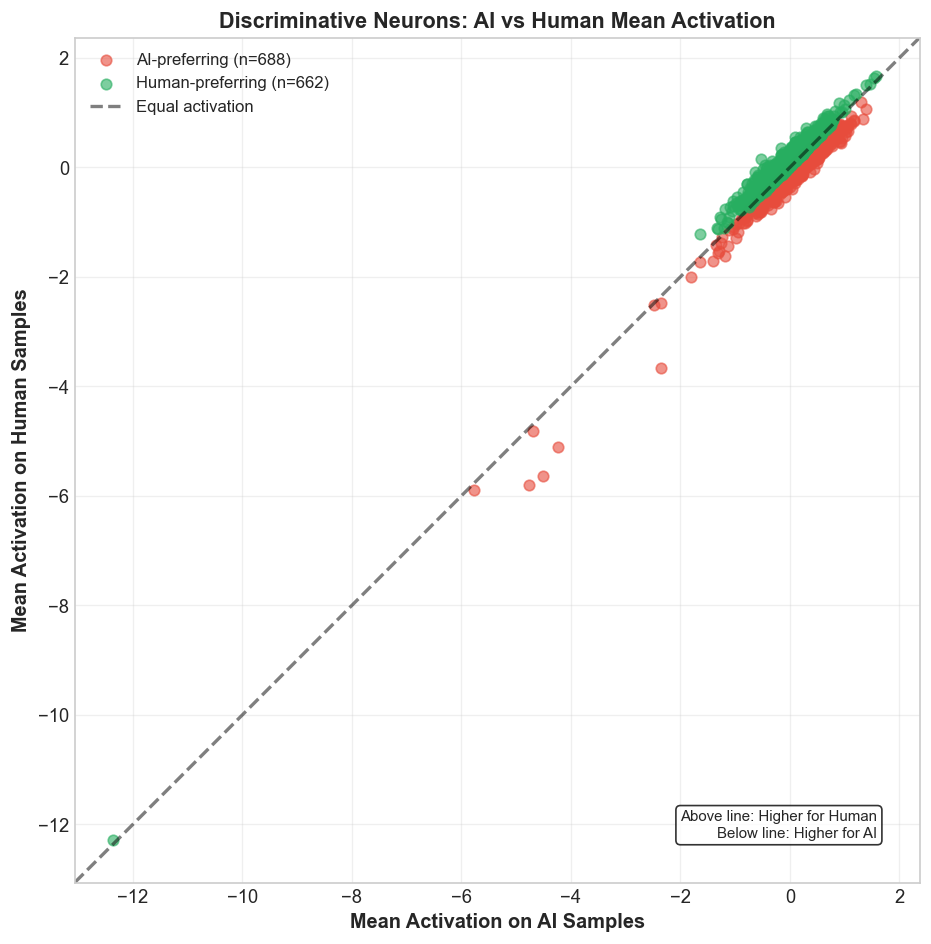

Saved: ..\results\figures\figure3_activation_scatter.png


In [18]:
# === FIGURE 3: Mean Activation Scatter (AI vs Human) ===
fig, ax = plt.subplots(figsize=(8, 8))

ai_pref_mask = disc_df['auc'] > 0.7
human_pref_mask = disc_df['auc'] < 0.3

ax.scatter(disc_df.loc[ai_pref_mask, 'ai_median'],
           disc_df.loc[ai_pref_mask, 'human_median'],
           c='#e74c3c', alpha=0.6, s=40, label=f'AI-preferring (n={ai_pref_mask.sum()})')
ax.scatter(disc_df.loc[human_pref_mask, 'ai_median'],
           disc_df.loc[human_pref_mask, 'human_median'],
           c='#27ae60', alpha=0.6, s=40, label=f'Human-preferring (n={human_pref_mask.sum()})')

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Equal activation')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('Mean Activation on AI Samples', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Activation on Human Samples', fontsize=12, fontweight='bold')
ax.set_title('Discriminative Neurons: AI vs Human Mean Activation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

ax.text(0.95, 0.05, 'Above line: Higher for Human\nBelow line: Higher for AI',
        transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'figure3_activation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_PATH / "figure3_activation_scatter.png"}')

---
# Section C: Statistical Validation
Prove findings are robust and neurons aren't redundant.

In [19]:
# === STATISTICAL VALIDATION ===
# Compute all validation metrics

# 1. Multiple testing correction
n_tests = len(neurons_df)
bonferroni_alpha = 0.05 / n_tests
n_survive = (disc_df['p_value'] < bonferroni_alpha).sum()
survive_pct = n_survive / len(disc_df) * 100

# 2. Effect sizes
large_d = (disc_df['cohens_d'].abs() > 0.8).sum()
large_d_pct = large_d / len(disc_df) * 100

# 3. P-value
median_p = disc_df['p_value'].median()

# 4. Correlation/redundancy (top 50 neurons)
top50 = disc_df.nlargest(50, 'auc_deviation')
activation_matrix = []
for _, row in top50.iterrows():
    layer = int(row['layer'])
    idx = int(row['neuron_idx'])
    acts = np.load(RESULTS_PATH / f'layer_{layer}_activations.npy')[:, idx]
    activation_matrix.append(acts)
activation_matrix = np.array(activation_matrix)
corr_matrix = np.corrcoef(activation_matrix)
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
mean_corr = np.abs(upper_tri).mean()

# Print compact table
print('STATISTICAL VALIDATION')
print('━'*45)
print(f"{'Multiple testing (Bonferroni)':<32} {survive_pct:.0f}% survived")
print(f"{'Large effect sizes (|d|>0.8)':<32} {large_d_pct:.1f}%")
print(f"{'Median p-value':<32} {median_p:.2e}")
print(f"{'Neuron independence (r̄)':<32} {mean_corr:.3f}")
print('━'*45)

STATISTICAL VALIDATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Multiple testing (Bonferroni)    100% survived
Large effect sizes (|d|>0.8)     84.3%
Median p-value                   8.68e-34
Neuron independence (r̄)         0.157
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
# Summary: Key Findings for Paper

In [20]:
print('='*70)
print('PAPER-READY KEY FINDINGS')
print('='*70)

print(f'''
SECTION A: NEURON DISCOVERY
- Identified {n_discriminative:,} discriminative neurons ({n_discriminative/n_total*100:.1f}% of {n_total:,} BERT neurons)
- {n_ai_pref:,} AI-preferring (AUC > 0.7), {n_human_pref:,} Human-preferring (AUC < 0.3)
- Late layers (9-12) contain {len(late):,} neurons ({len(late)/n_discriminative*100:.1f}% of discriminative)
- Peak: Layer {peak_layer} with {peak_count} neurons

SECTION B: ACTIVATION PATTERNS
- Mean |Cohen's d|: {disc_df['cohens_d'].abs().mean():.3f}
- Large effects (|d| > 0.8): {large_d} neurons
- {(disc_df['mean_diff'] > 0).sum()} neurons activate higher for AI text
- {(disc_df['mean_diff'] < 0).sum()} neurons activate higher for Human text

SECTION C: VALIDATION
- {n_survive}/{len(disc_df)} neurons survive Bonferroni correction ({survive_pct:.0f}%)
- Median p-value: {median_p:.2e}
- Mean neuron correlation: {mean_corr:.3f} (low redundancy)
''')

print('='*70)
print('FIGURES FOR PAPER:')
print(f'  1. figure1_layer_distribution.png')
print(f'  2. figure2_activation_boxplots.png')
print(f'  3. figure3_activation_scatter.png')
print('='*70)

PAPER-READY KEY FINDINGS

SECTION A: NEURON DISCOVERY
- Identified 1,350 discriminative neurons (14.6% of 9,216 BERT neurons)
- 688 AI-preferring (AUC > 0.7), 662 Human-preferring (AUC < 0.3)
- Late layers (9-12) contain 604 neurons (44.7% of discriminative)
- Peak: Layer 11 with 181 neurons

SECTION B: ACTIVATION PATTERNS
- Mean |Cohen's d|: 0.967
- Large effects (|d| > 0.8): 1138 neurons
- 688 neurons activate higher for AI text
- 662 neurons activate higher for Human text

SECTION C: VALIDATION
- 1350/1350 neurons survive Bonferroni correction (100%)
- Median p-value: 8.68e-34
- Mean neuron correlation: 0.157 (low redundancy)

FIGURES FOR PAPER:
  1. figure1_layer_distribution.png
  2. figure2_activation_boxplots.png
  3. figure3_activation_scatter.png
